## v1 Curious Assignment 07_10_26 (Amiri)

In [ ]:
# (4 Steps Python Enviroment)
# (1) Dependencies
# (2) Install Packages
# (3) Source Paths
# (4) Load from S3 open CSV files

In [1]:
import subprocess, sys

# Pin the entire boto stack atomically — all four packages must be compatible
boto_stack = [
    "aiobotocore==3.7.0",
    "botocore==1.43.0",
    "boto3==1.43.0",
    "s3fs==2026.6.0",
]

# Install boto stack with --no-deps to prevent pip from overriding the pins
subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet",
                       "--force-reinstall"] + boto_stack)

# Install all other dependencies normally
subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet",
                       "aioitertools", "h5py", "geopandas", "xarray", "netCDF4", "pyarrow"])

print("All dependencies installed.")

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
awscli 1.45.42 requires botocore==1.43.42, but you have botocore 1.43.0 which is incompatible.
awscli 1.45.42 requires s3transfer<0.20.0,>=0.19.0, but you have s3transfer 0.17.1 which is incompatible.
sagemaker 2.257.3 requires attrs<26,>=24, but you have attrs 26.1.0 which is incompatible.


All dependencies installed.


In [2]:
import pandas as pd
import s3fs

## Exercise 1 — Read two CSV files: 

#### Note: 
(1) For this exercise rather than the GEDI/GEDI02_A/002/ Directory (s3) used in the example file we were asked to use prefixes gedi-county-summary/ & gedi02B-county-summary/.

(2) gedi-county-summary is canopy height data & gedi02B-county-summary/ is canopy cover data

**S3 source paths (confirmed):**
- HEIGHT: `s3://central-virginia-tree-canopy-project/gedi-county-summary/virginia_gedi_county_summary-cville.csv`
- COVER: `s3://central-virginia-tree-canopy-project/gedi02B-county-summary/virginia_gedi02B_county-cover_summary.csv`

### S1 - Imports and Configuration

In [3]:
# ── S3 source paths ───────────────────────────────────────────────────────────
S3_BUCKET     = "central-virginia-tree-canopy-project"
HEIGHT_S3_KEY = "gedi-county-summary/virginia_gedi_county_summary-cville.csv"
COVER_S3_KEY = "gedi02B-county-summary/virginia_gedi02B_county-cover_summary.csv"

print("Imports and configuration complete.")
print(f"  HEIGHT source: s3://{S3_BUCKET}/{HEIGHT_S3_KEY}")
print(f"  COVER  source: s3://{S3_BUCKET}/{COVER_S3_KEY}")

Imports and configuration complete.
  HEIGHT source: s3://central-virginia-tree-canopy-project/gedi-county-summary/virginia_gedi_county_summary-cville.csv
  COVER  source: s3://central-virginia-tree-canopy-project/gedi02B-county-summary/virginia_gedi02B_county-cover_summary.csv


### S2 - Load Data from S3

In [4]:
fs = s3fs.S3FileSystem(anon=False)

# (A) Directory 1: Load Virginia gedi county summary cville (HEIGHT)
height_s3_path = f"s3://{S3_BUCKET}/{HEIGHT_S3_KEY}"
print(f"Loading HEIGHT from : {height_s3_path}")
with fs.open(height_s3_path, "rb") as f:
    height_df = pd.read_csv(f)

# Select and order the exact columns: year, jurisdiction, canopy_height_mean_m
#! After trail & error I learned that I needed to add another line of code to isolate the specific colums I wanted to add since there is more than one I wanted to highlight for this data set
height_df = height_df[['year', 'jurisdiction', 'canopy_height_mean_m']]
height_df['year'] = height_df['year'].astype(int)

print(f"\nHEIGHT shape : {height_df.shape} | years : {sorted(height_df['year'].unique())}")
print(f"HEIGHT jurisdictions : {sorted(height_df['jurisdiction'].unique())}")

print("\n--- HEIGHT preview (first 3 rows) ---")
display(height_df.head(3))


# (B) Directory 2:
#! Remember to change height_df & HEIGHTS (below) to cover_df & COVER
cover_s3_path = f"s3://{S3_BUCKET}/{COVER_S3_KEY}"
print(f"Loading COVER from : {cover_s3_path}")
with fs.open(cover_s3_path, "rb") as f:
    cover_df = pd.read_csv(f)

# Select and order the exact columns: jurisdiction, year, mean_canopy_cover, total_valid_shots
cover_df = cover_df[['jurisdiction', 'year', 'mean_canopy_cover', 'total_valid_shots']]

#! At first I made the mistake of putting jurisdiction below because it is the furthest left column; but for astype(int) to work it has to be a number so 'year'
cover_df['year'] = cover_df['year'].astype(int)

print(f"\nCOVER shape : {cover_df.shape} | jurisdictions : {sorted(cover_df['jurisdiction'].unique())}")
print(f"COVER years : {sorted(cover_df['year'].unique())}")

print("\n--- COVER preview (first 10 rows) ---")
display(cover_df.head(10))

Loading HEIGHT from : s3://central-virginia-tree-canopy-project/gedi-county-summary/virginia_gedi_county_summary-cville.csv

HEIGHT shape : (5, 3) | years : [np.int64(2019), np.int64(2021), np.int64(2022), np.int64(2024), np.int64(2025)]
HEIGHT jurisdictions : ['Charlottesville']

--- HEIGHT preview (first 3 rows) ---


,year,jurisdiction,canopy_height_mean_m
0,2019,Charlottesville,16.583230
1,2021,Charlottesville,12.467922
2,2022,Charlottesville,16.108187


Loading COVER from : s3://central-virginia-tree-canopy-project/gedi02B-county-summary/virginia_gedi02B_county-cover_summary.csv

COVER shape : (61, 4) | jurisdictions : ['Albemarle', 'Augusta', 'Buckingham', 'Charlottesville', 'Fluvanna', 'Greene', 'Louisa', 'Nelson', 'Rockingham']
COVER years : [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]

--- COVER preview (first 10 rows) ---


,jurisdiction,year,mean_canopy_cover,total_valid_shots
0,Albemarle,2019,0.529159,53356
1,Albemarle,2020,0.540116,14835
2,Albemarle,2021,0.424221,54570
3,Albemarle,2022,0.459664,47618
4,Albemarle,2023,0.207803,11110
5,Albemarle,2024,0.512670,31573
6,Albemarle,2025,0.404998,27296
7,Augusta,2019,0.412462,23961
8,Augusta,2020,0.233118,28070
9,Augusta,2021,0.374634,33316


## Exercise 2 — "Be Curious":

In [5]:
# ── HEIGHT Average by Year (No mixing of unequal counties) ────────────────────
yearly_height = height_df.groupby('year')['canopy_height_mean_m'].mean()

print("── CHRONOLOGICAL HEIGHT progression ───────────────────────────────────")
for year, height in yearly_height.items():
    print(f"📅 Year {year} ➔ Regional Mean Canopy Height: {height:.2f} meters")

── CHRONOLOGICAL HEIGHT progression ───────────────────────────────────
📅 Year 2019 ➔ Regional Mean Canopy Height: 16.58 meters
📅 Year 2021 ➔ Regional Mean Canopy Height: 12.47 meters
📅 Year 2022 ➔ Regional Mean Canopy Height: 16.11 meters
📅 Year 2024 ➔ Regional Mean Canopy Height: 19.09 meters
📅 Year 2025 ➔ Regional Mean Canopy Height: 8.85 meters


  Using cached matplotlib-3.10.9-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (52 kB)
  Using cached contourpy-1.3.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (118 kB)
  Using cached kiwisolver-1.5.0-cp310-cp310-manylinux_2_12_x86_64.manylinux2010_x86_64.whl.metadata (5.1 kB)
  Using cached pillow-12.3.0-cp310-cp310-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (9.1 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.9-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (8.8 MB)
Using cached contourpy-1.3.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (325 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.63.0-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x

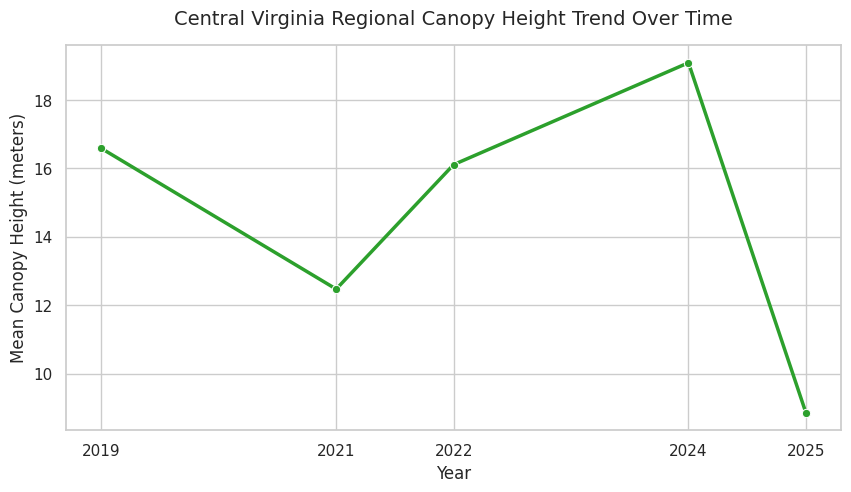

Visual trend plot rendered successfully.


In [7]:
%pip install matplotlib seaborn

import matplotlib.pyplot as plt
import seaborn as sns

# ── Visualization Settings & Theme ──────────────────────────────────────────
FIG_WIDTH, FIG_HEIGHT = 10, 5
LINE_WIDTH            = 2.5
MARKER_STYLE          = "o"
PLOT_STYLE            = "whitegrid"
GEDI_COLOUR           = "#2ca02c"   # green - canopy height

print("Visualization configuration loaded.")
print(f"  Canvas size  : {FIG_WIDTH}x{FIG_HEIGHT}")
print(f"  Line colour  : {GEDI_COLOUR}")
print("── GENERATING REGIONAL CANOPY TREND VISUAL ─────────────────────────────")

# ── Data aggregation matrix operation ─────────────────────────────────────────
yearly_height_df = height_df.groupby('year')['canopy_height_mean_m'].mean().reset_index()

# ── Canvas execution & layout formatting ──────────────────────────────────────
sns.set_theme(style=PLOT_STYLE)
plt.figure(figsize=(FIG_WIDTH, FIG_HEIGHT))

sns.lineplot(
    data=yearly_height_df, 
    x='year', 
    y='canopy_height_mean_m', 
    marker=MARKER_STYLE,          
    linewidth=LINE_WIDTH, 
    color=GEDI_COLOUR      
)

plt.title('Central Virginia Regional Canopy Height Trend Over Time', fontsize=14, pad=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Mean Canopy Height (meters)', fontsize=12)
plt.xticks(yearly_height_df['year'].unique()) 

plt.show()
print("Visual trend plot rendered successfully.")

In [8]:
# ── COVER Dataset Statistics ─────────────────────────────────────────────────
cover_mean   = cover_df['mean_canopy_cover'].mean()
cover_median = cover_df['mean_canopy_cover'].median()
cover_mode   = cover_df['mean_canopy_cover'].mode().iloc[0]

print("\n── COVER METRIC SUMMARY ────────────────────────────────────────────────")
print(f"📊 Mean (Average) Cover   : {cover_mean:.2f}%")
print(f"🎯 Median (Middle) Cover  : {cover_median:.2f}%")
print(f"🔝 Mode (Most Common)     : {cover_mode:.2f}%")


── COVER METRIC SUMMARY ────────────────────────────────────────────────
📊 Mean (Average) Cover   : 0.40%
🎯 Median (Middle) Cover  : 0.40%
🔝 Mode (Most Common)     : 0.12%


In [9]:
# ── Configuration: Target jurisdictions in exact order ───────────────────────
TARGET_JURISDICTIONS = [
    "Albemarle",
    "Augusta",
    "Buckingham",
    "Charlottesville",
    "Fluvanna",
    "Greene",
    "Louisa",
    "Nelson",
    "Rockingham"
]

print("Configuration loaded.")
print(f"  Target jurisdictions: {len(TARGET_JURISDICTIONS)} regions loaded.")
print("── COVER METRICS BY JURISDICTION ────────────────────────────────────────")

# ── Metrics aggregation execution loop ────────────────────────────────────────
for county in TARGET_JURISDICTIONS:
    county_df = cover_df[cover_df['jurisdiction'] == county]
    
    if not county_df.empty:
        c_mean   = county_df['mean_canopy_cover'].mean()
        c_median = county_df['mean_canopy_cover'].median()
        c_mode   = county_df['mean_canopy_cover'].mode().iloc[0]
        
        print(f"\n📍 {county.upper()}:")
        print(f"   📊 Mean (Average) : {c_mean:.2f}%")
        print(f"   🎯 Median (Middle): {c_median:.2f}%")
        print(f"   🔝 Mode (Common)  : {c_mode:.2f}%")
    else:
        print(f"\n📍 {county.upper()}: ⚠️ No data found in the COVER dataset.")

Configuration loaded.
  Target jurisdictions: 9 regions loaded.
── COVER METRICS BY JURISDICTION ────────────────────────────────────────

📍 ALBEMARLE:
   📊 Mean (Average) : 0.44%
   🎯 Median (Middle): 0.46%
   🔝 Mode (Common)  : 0.21%

📍 AUGUSTA:
   📊 Mean (Average) : 0.30%
   🎯 Median (Middle): 0.32%
   🔝 Mode (Common)  : 0.12%

📍 BUCKINGHAM:
   📊 Mean (Average) : 0.40%
   🎯 Median (Middle): 0.44%
   🔝 Mode (Common)  : 0.19%

📍 CHARLOTTESVILLE:
   📊 Mean (Average) : 0.39%
   🎯 Median (Middle): 0.42%
   🔝 Mode (Common)  : 0.25%

📍 FLUVANNA:
   📊 Mean (Average) : 0.43%
   🎯 Median (Middle): 0.46%
   🔝 Mode (Common)  : 0.19%

📍 GREENE:
   📊 Mean (Average) : 0.39%
   🎯 Median (Middle): 0.39%
   🔝 Mode (Common)  : 0.23%

📍 LOUISA:
   📊 Mean (Average) : 0.40%
   🎯 Median (Middle): 0.39%
   🔝 Mode (Common)  : 0.21%

📍 NELSON:
   📊 Mean (Average) : 0.52%
   🎯 Median (Middle): 0.53%
   🔝 Mode (Common)  : 0.29%

📍 ROCKINGHAM:
   📊 Mean (Average) : 0.31%
   🎯 Median (Middle): 0.29%
   🔝 Mode (C